<a href="https://colab.research.google.com/github/Pratap43/hotel-booking-predictor/blob/main/Hotel_Booking_Demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [169]:
import joblib
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [172]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [178]:
# Save column names
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [179]:
from google.colab import files
files.download("columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 1. Data Cleaning and Preprocessing

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
df = pd.read_csv('hotel_bookings.csv')
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [123]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [124]:
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
df['children'] = df['children'].fillna(df['children'].median())
df['country'] = df['country'].fillna(df['country'].mode()[0])

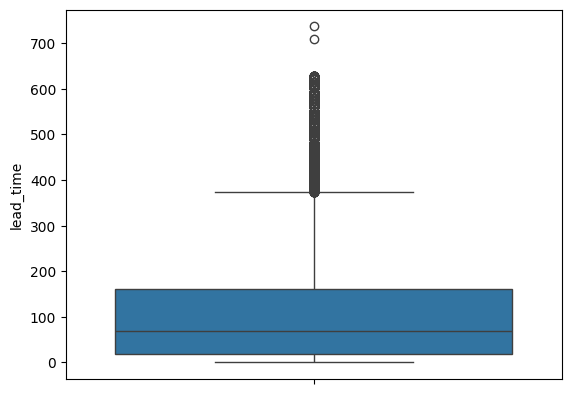

In [125]:
sns.boxplot(df['lead_time'])
plt.show()

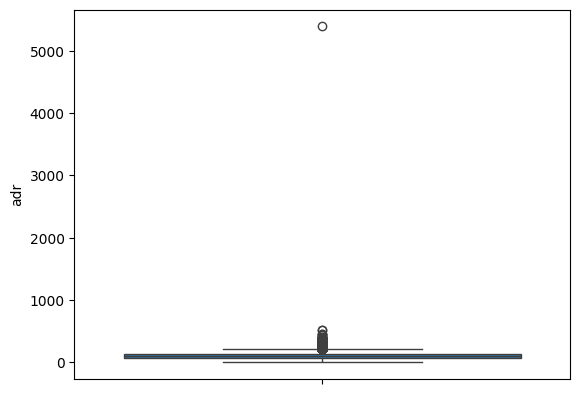

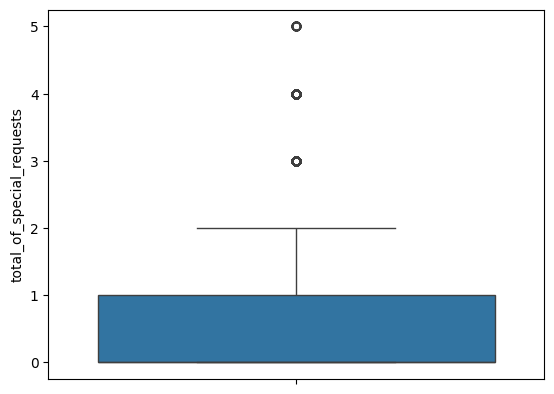

In [126]:
sns.boxplot(df['adr'])
plt.show()

sns.boxplot(df['total_of_special_requests'])
plt.show()

In [127]:
def cap_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = np.clip(df[col], lower, upper)

cap_outliers('lead_time')
cap_outliers('adr')
cap_outliers('total_of_special_requests')

In [128]:
df.dropna(subset=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(int).astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(int).astype(str),
    format='%Y-%B-%d'
)

In [129]:
df['arrival_date'].head()

,arrival_date
0,2015-07-01
1,2015-07-01
2,2015-07-01
3,2015-07-01
4,2015-07-01


In [130]:
df.head()
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [131]:
categorical_cols = [
    'hotel', 'market_segment', 'distribution_channel',
    'meal', 'deposit_type', 'customer_type', 'reservation_status', 'country',
    'reserved_room_type', 'assigned_room_type'
]

In [132]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [133]:
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P
0,0,342,2015,July,27,1,0,0,2,0.0,...,True,False,False,False,False,False,False,False,False,False
1,0,373,2015,July,27,1,0,0,2,0.0,...,True,False,False,False,False,False,False,False,False,False
2,0,7,2015,July,27,1,0,1,1,0.0,...,True,False,False,False,False,False,False,False,False,False
3,0,13,2015,July,27,1,0,1,1,0.0,...,False,False,False,False,False,False,False,False,False,False
4,0,14,2015,July,27,1,0,2,2,0.0,...,False,False,False,False,False,False,False,False,False,False


In [134]:
numerical_cols = [
    'lead_time', 'adr', 'previous_cancellations',
    'total_of_special_requests'
]

In [135]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [136]:
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P
0,0,2.370249,2015,July,27,1,0,0,2,0.0,...,True,False,False,False,False,False,False,False,False,False
1,0,2.676699,2015,July,27,1,0,0,2,0.0,...,True,False,False,False,False,False,False,False,False,False
2,0,-0.941386,2015,July,27,1,0,1,1,0.0,...,True,False,False,False,False,False,False,False,False,False
3,0,-0.882073,2015,July,27,1,0,1,1,0.0,...,False,False,False,False,False,False,False,False,False,False
4,0,-0.872187,2015,July,27,1,0,2,2,0.0,...,False,False,False,False,False,False,False,False,False,False


# 2. Feature Engineeering

**6.Loyalty Feature**

In [137]:
df['is_repeat_booking'] = df['is_repeated_guest']

**7.Booking Pressure Feature**

In [138]:
df['days_until_arrival_per_room'] = df['lead_time'] / (df['adr'] + 1)

**8.Guest Composition Feature**

Total Guests

In [139]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

Family Flag

In [140]:
df['family_flag'] = ((df['children'] + df['babies']) > 0).astype(int)

**9.Booking Change Feature**

Change Flag

In [141]:
df['change_flag'] = (df['booking_changes'] > 0).astype(int)

Number of Changes

In [142]:
df['num_changes'] = df['booking_changes']

**10.Revenue Potential Feature**

In [143]:
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['potential_revenue'] = df['adr'] * df['total_stay_nights']

In [144]:
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type_L,assigned_room_type_P,is_repeat_booking,days_until_arrival_per_room,total_guests,family_flag,change_flag,num_changes,total_stay_nights,potential_revenue
0,0,2.370249,2015,July,27,1,0,0,2,0.0,...,False,False,0,-1.892486,2.0,0,1,3,0,-0.000000
1,0,2.676699,2015,July,27,1,0,0,2,0.0,...,False,False,0,-2.137166,2.0,0,1,4,0,-0.000000
2,0,-0.941386,2015,July,27,1,0,1,1,0.0,...,False,False,0,-2.210749,1.0,0,0,0,1,-0.574178
3,0,-0.882073,2015,July,27,1,0,1,1,0.0,...,False,False,0,-2.071459,1.0,0,0,0,1,-0.574178
4,0,-0.872187,2015,July,27,1,0,2,2,0.0,...,False,False,0,-0.927373,2.0,0,0,0,2,-0.119014


In [145]:
df[['is_repeat_booking','total_guests','family_flag','potential_revenue']].head()

,is_repeat_booking,total_guests,family_flag,potential_revenue
0,0,2.0,0,-0.000000
1,0,2.0,0,-0.000000
2,0,1.0,0,-0.574178
3,0,1.0,0,-0.574178
4,0,2.0,0,-0.119014


# 3. Model Building

**11. Define Features & Target**

**13. Train-Test Split**

In [146]:
# Define target variable
y = df['is_canceled']

# Identify columns to drop from features (leakage, non-numeric, redundant)
columns_to_drop = [
    'is_canceled', # Target variable
    'reservation_status_Check-Out', # Leakage from reservation_status
    'reservation_status_No-Show',   # Leakage from reservation_status
    'reservation_status_date',      # Leakage date column
    'arrival_date_month',           # String/categorical
    'arrival_date',                 # Datetime object
    'is_repeated_guest'             # Redundant with 'is_repeat_booking'
]

# Dynamically check which columns exist in df before dropping to avoid KeyError
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# Define features X by dropping specified columns
X = df.drop(columns=existing_columns_to_drop, axis=1)

# Check if any text column left after dropping explicitly identified columns.
print("Text columns:", X.select_dtypes(include='object').columns)

Text columns: Index([], dtype='object')


In [147]:
# This cell was removed because it caused a KeyError.
# The columns 'country', 'reserved_room_type', and 'assigned_room_type'
# were already one-hot encoded in cell MIlA6PQHnXF9.

In [148]:
# This cell incorrectly redefined X and y after they were properly set in rhOI6wOJs3az.
# X = df.drop('is_canceled', axis=1)
# y = df['is_canceled']

In [149]:
# This cell incorrectly redefined X and y after they were properly set in rhOI6wOJs3az.
# X = df.drop('is_canceled', axis=1)
# y = df['is_canceled']

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**11. Model 1 — Logistic Regression**

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Now that X is fully numeric, we can fit the model directly
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.813803501130748


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**11. Model 2 — Random Forest**

In [167]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.891657592763213


**12. Hyperparameter Tuning**

In [168]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


**Use Best Model**

In [170]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Model Accuracy: 0.8142222966747634


**14. Cross Validation**

In [171]:
from sklearn.model_selection import cross_val_score

# Using the tuned best_model for cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-validation scores: [0.68322305 0.74193819 0.72820169 0.7365776  0.66228327]
Mean Accuracy: 0.7104447608677444


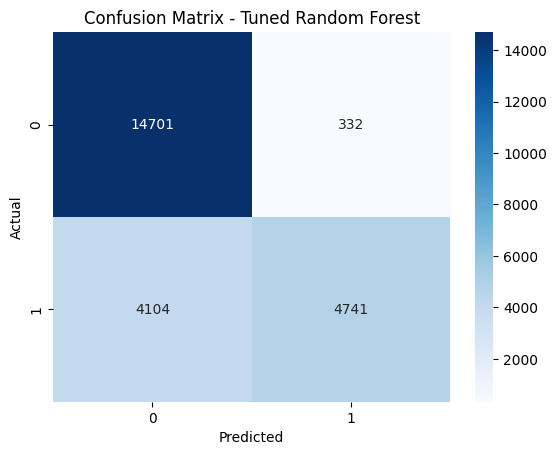

In [173]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

# 4. Model Evaluation

**15. Evaluation Metrics**

In [154]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [155]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8003601641678533
Precision: 0.945391000436872
Recall: 0.4893159977388355
F1 Score: 0.6448632943455264


In [156]:
y_prob = best_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9181981325651118


**16. Plot ROC Curve**

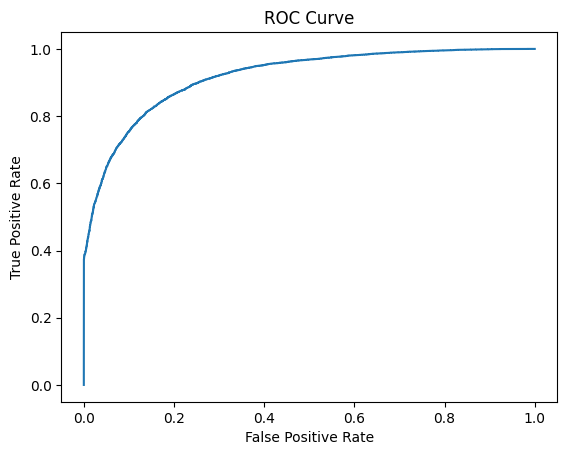

In [157]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**17. Feature Importance**

**If using Random Forest(Best)**

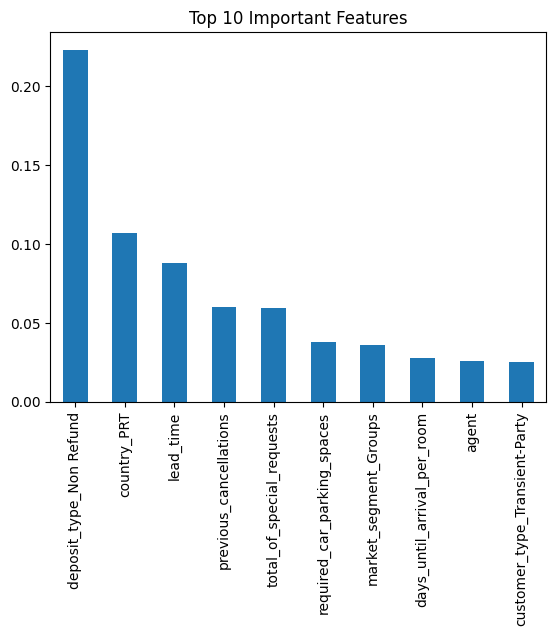

In [158]:
import pandas as pd

importance = best_model.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)

feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

**If using Logistic Regression**

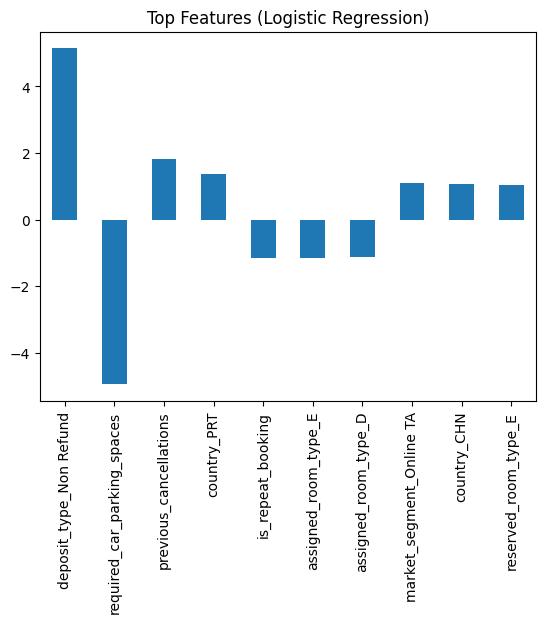

In [159]:
importance = lr.coef_[0]

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values(key=abs, ascending=False).head(10).plot(kind='bar')
plt.title("Top Features (Logistic Regression)")
plt.show()

#5.Business Insights And Deployment

In [160]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = feat_imp.sort_values(ascending=False).head(10)
print(top_features)

deposit_type_Non Refund          0.223277
country_PRT                      0.107058
lead_time                        0.088168
previous_cancellations           0.060079
total_of_special_requests        0.059477
required_car_parking_spaces      0.037819
market_segment_Groups            0.035981
days_until_arrival_per_room      0.027726
agent                            0.025960
customer_type_Transient-Party    0.025062
dtype: float64


In [161]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [162]:
expected_cancellations = y_prob.sum()
print("Expected cancellations:", expected_cancellations)

Expected cancellations: 8789.129537691666


In [163]:
total_bookings = len(X_test)

overbooking_limit = int(0.05 * total_bookings)

print("Allowed overbooking:", overbooking_limit)

Allowed overbooking: 1193


In [164]:
extra_bookings = min(expected_cancellations, overbooking_limit)

print("Recommended extra bookings:", int(extra_bookings))

Recommended extra bookings: 1193


**20. FAIRNESS / BIAS ANALYSIS**

In [165]:
# To analyze bias on original categorical columns,
# we need to ensure the 'hotel' column is available.
# Since df was already one-hot encoded, let's reload the original data
# and apply necessary preprocessing steps up to this point.

# Temporarily reload the dataset for this bias analysis
temp_df = pd.read_csv('hotel_bookings.csv')

# Apply the same cleaning and preprocessing steps as done previously,
# but *before* one-hot encoding the 'hotel' column.

# Fill missing values (as in PKt6E7jCj24E)
temp_df['agent'] = temp_df['agent'].fillna(0)
temp_df['company'] = temp_df['company'].fillna(0)
temp_df['children'] = temp_df['children'].fillna(temp_df['children'].median())
temp_df['country'] = temp_df['country'].fillna(temp_df['country'].mode()[0])

# Ensure date columns are processed before dropping NaNs (as in j-zzEgX5kvSF)
# Drop rows with any NaN in date components first, to prevent errors in to_datetime
temp_df.dropna(subset=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'], inplace=True)
temp_df['arrival_date'] = pd.to_datetime(
    temp_df['arrival_date_year'].astype(int).astype(str) + '-' +
    temp_df['arrival_date_month'] + '-' +
    temp_df['arrival_date_day_of_month'].astype(int).astype(str),
    format='%Y-%B-%d'
)

# Outlier capping (as in SHo4z_qqknFk)
def cap_outliers_temp(col_name):
    q1 = temp_df[col_name].quantile(0.25)
    q3 = temp_df[col_name].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    temp_df[col_name] = np.clip(temp_df[col_name], lower, upper)

cap_outliers_temp('lead_time')
cap_outliers_temp('adr')
cap_outliers_temp('total_of_special_requests')

# Now perform the groupby operation on the temporary DataFrame
print(temp_df.groupby('hotel')['is_canceled'].mean())

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64


In [175]:
# Use temp_df which contains the original categorical columns
temp_df.groupby('market_segment')['is_canceled'].mean()

,is_canceled
market_segment,
Aviation,0.219409
Complementary,0.130552
Corporate,0.187347
Direct,0.153419
Groups,0.610620
Offline TA/TO,0.343160
Online TA,0.367211
Undefined,1.000000


In [177]:
# Use the indices from X_test to get the corresponding rows from temp_df
bias_df = temp_df.loc[X_test.index].copy()
bias_df['predicted'] = y_pred

bias_check = bias_df.groupby('hotel')['predicted'].mean()
print("Predicted Cancellation Rate by Hotel Type:")
print(bias_check)

Predicted Cancellation Rate by Hotel Type:
hotel
City Hotel      0.225786
Resort Hotel    0.125784
Name: predicted, dtype: float64
